# K-Nearest Neighbors (KNN) -- From Scratch

## What is KNN?

**K-Nearest Neighbors** is one of the simplest and most intuitive machine learning algorithms.
The idea is straightforward:

> *"Tell me who your neighbors are, and I'll tell you who you are."*

### How does it work?

1. **Pick a number K** (e.g. K = 5).
2. For a new data point you want to classify, **measure the distance** to every point in the training set.
3. **Find the K closest** (nearest) training points.
4. **Take a vote** -- whichever class appears most among those K neighbors is the prediction.

That's it! No training phase, no weight updates, no gradient descent. KNN simply **memorizes** the training data and compares at prediction time.

<p align="center">
  <img src="https://miro.medium.com/v2/resize:fit:828/format:webp/0*jqxx3-dJqFjXD6FA.gif" width="500"/>
</p>

---


## Load & Explore the Data

We will use the **Social Network Ads** dataset.
It contains information about users and whether they **purchased** a product after seeing an ad.

| Column | Description |
|--------|-------------|
| `Age` | Age of the user |
| `EstimatedSalary` | Estimated annual salary |
| `Purchased` | **Target** -- 0 (did not purchase) or 1 (purchased) |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


data = pd.read_csv("Data_SET/Social_Network_Ads.csv")

data.head(10)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
5,27,58000,0
6,27,84000,0
7,32,150000,1
8,25,33000,0
9,35,65000,0


In [ ]:

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [ ]:

data.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [ ]:

print("Missing values per column:")
print(data.isnull().sum())
print(f"\nTotal missing values: {data.isnull().sum().sum()}")

Missing values per column:
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Total missing values: 0


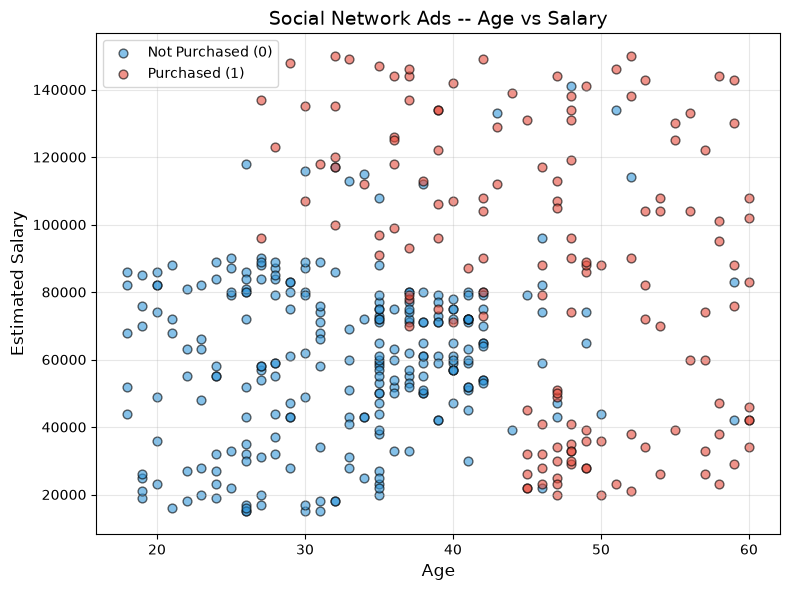

In [ ]:

plt.figure(figsize=(8, 6))

purchased = data[data['Purchased'] == 1]
not_purchased = data[data['Purchased'] == 0]

plt.scatter(not_purchased['Age'], not_purchased['EstimatedSalary'],
            color='#3498db', label='Not Purchased (0)', alpha=0.6, edgecolors='k', s=40)
plt.scatter(purchased['Age'], purchased['EstimatedSalary'],
            color='#e74c3c', label='Purchased (1)', alpha=0.6, edgecolors='k', s=40)

plt.xlabel('Age', fontsize=12)
plt.ylabel('Estimated Salary', fontsize=12)
plt.title('Social Network Ads -- Age vs Salary', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## The Math Behind KNN

KNN relies on two simple ideas: **distance** and **voting**.

---

### 1. Distance -- How far apart are two points?

We use **Euclidean Distance** (the straight-line distance between two points):

$$d(\mathbf{p}, \mathbf{q}) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}$$

For our 2-feature case (Age, Salary):

$$d = \sqrt{(Age_1 - Age_2)^2 + (Salary_1 - Salary_2)^2}$$

---

### 2. Majority Voting -- What do the neighbors say?

Once we find the **K nearest** training points:

$$\hat{y} = \text{mode}(y_1, y_2, \dots, y_K)$$

We simply count which class appears most often among the K neighbors -- that's our prediction.

---

### Why do we need Feature Scaling?

Age ranges from ~18 to 60, but Salary ranges from ~15,000 to 150,000.
Without scaling, **salary would dominate the distance** calculation, making age almost irrelevant.

We fix this using **Min-Max Normalization**:

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

This maps every feature to the range **[0, 1]**.


## Data Preprocessing

We'll do everything **manually with NumPy** -- no scikit-learn.

1. Extract features (X) and target (y)
2. Shuffle the data randomly
3. Split into training (80%) and test (20%) sets
4. Apply Min-Max normalization to features


In [ ]:

X = data[['Age', 'EstimatedSalary']].values  
y = data['Purchased'].values                  

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"Class distribution: 0 -> {np.sum(y == 0)}, 1 -> {np.sum(y == 1)}")

Features shape: (400, 2)
Target shape:   (400,)
Class distribution: 0 -> 257, 1 -> 143


In [ ]:


np.random.seed(42)  


indices = np.arange(len(X))
np.random.shuffle(indices)


X_shuffled = X[indices]
y_shuffled = y[indices]

split_point = int(0.8 * len(X))

X_train = X_shuffled[:split_point]
X_test  = X_shuffled[split_point:]
y_train = y_shuffled[:split_point]
y_test  = y_shuffled[split_point:]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 320 samples
Test set:     80 samples


In [ ]:


X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)

X_train_scaled = (X_train - X_min) / (X_max - X_min)
X_test_scaled  = (X_test  - X_min) / (X_max - X_min)

print("Before scaling (first 3 rows):")
print(X_train[:3])
print("\nAfter scaling (first 3 rows):")
print(X_train_scaled[:3])

Before scaling (first 3 rows):
[[   46 22000]
 [   59 88000]
 [   28 44000]]

After scaling (first 3 rows):
[[0.66666667 0.05185185]
 [0.97619048 0.54074074]
 [0.23809524 0.21481481]]


## KNN Implementation -- From Scratch

Here we build the KNN classifier as a clean Python class using only NumPy.


In [ ]:
class KNN:
    """K-Nearest Neighbors classifier built from scratch."""

    def __init__(self, k=3):
        """Initialize with the number of neighbors to consider."""
        self.k = k

    def fit(self, X_train, y_train):
        """Store the training data (KNN is a lazy learner - no actual training)."""
        self.X_train = X_train
        self.y_train = y_train

    def _euclidean_distance(self, x1, x2):
        """Compute Euclidean distance between two points."""
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def _predict_single(self, x):
        """Predict the class for a single test point."""

  
        distances = np.array([self._euclidean_distance(x, x_train)
                              for x_train in self.X_train])

        
        k_indices = np.argsort(distances)[:self.k]

        k_labels = self.y_train[k_indices]

        values, counts = np.unique(k_labels, return_counts=True)
        majority_class = values[np.argmax(counts)]

        return majority_class

    def predict(self, X_test):
        """Predict classes for an array of test points."""
        return np.array([self._predict_single(x) for x in X_test])

In [17]:

knn = KNN(k=7)
knn.fit(X_train_scaled, y_train)


y_pred = knn.predict(X_test_scaled)


print("First 15 predictions vs actual:")
print(f"Predicted: {y_pred[:15]}")
print(f"Actual:    {y_test[:15]}")

First 15 predictions vs actual:
Predicted: [1 0 1 0 1 1 0 0 0 0 0 0 0 0 1]
Actual:    [0 0 1 0 1 1 1 0 0 0 0 0 0 0 1]


## Model Evaluation

We evaluate using:
- **Accuracy** -- percentage of correct predictions
- **Confusion Matrix** -- breakdown of true/false positives and negatives

All computed manually with NumPy.


In [ ]:

accuracy = np.sum(y_pred == y_test) / len(y_test)
print(f"Accuracy (k=5): {accuracy * 100:.2f}%")

Accuracy (k=5): 88.75%


In [ ]:


def confusion_matrix(y_true, y_pred, classes):
    """Build a confusion matrix manually."""
    n = len(classes)
    matrix = np.zeros((n, n), dtype=int)
    for true, pred in zip(y_true, y_pred):
        i = np.where(classes == true)[0][0]   
        j = np.where(classes == pred)[0][0]    
        matrix[i, j] += 1
    return matrix

classes = np.array([0, 1])
cm = confusion_matrix(y_test, y_pred, classes)

print("Confusion Matrix:")
print(f"                 Predicted 0   Predicted 1")
print(f"  Actual 0          {cm[0,0]:>3}           {cm[0,1]:>3}")
print(f"  Actual 1          {cm[1,0]:>3}           {cm[1,1]:>3}")


TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Confusion Matrix:
                 Predicted 0   Predicted 1
  Actual 0           49             6
  Actual 1            3            22

Precision: 0.7857
Recall:    0.8800
F1 Score:  0.8302


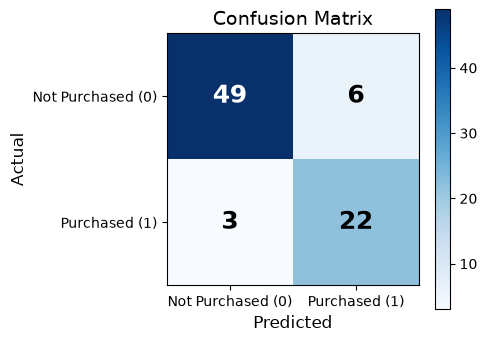

In [ ]:

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')

# Labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Purchased (0)', 'Purchased (1)'])
ax.set_yticklabels(['Not Purchased (0)', 'Purchased (1)'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14)

for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=18, fontweight='bold', color=color)

plt.colorbar(im)
plt.tight_layout()
plt.show()

## Testing Different K Values

The choice of **K** matters:
- **K too small** (e.g. 1) -> the model is sensitive to noise (overfitting)
- **K too large** (e.g. 100) -> the model becomes too general (underfitting)

Let's test a range of K values and plot accuracy to find the **sweet spot**.


In [ ]:

k_values = range(1, 26)
accuracies = []

for k in k_values:
    model = KNN(k=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = np.sum(preds == y_test) / len(y_test)
    accuracies.append(acc)
    print(f"K = {k:>2}  ->  Accuracy: {acc * 100:.2f}%")

K =  1  ->  Accuracy: 83.75%
K =  2  ->  Accuracy: 82.50%
K =  3  ->  Accuracy: 88.75%
K =  4  ->  Accuracy: 86.25%
K =  5  ->  Accuracy: 88.75%
K =  6  ->  Accuracy: 87.50%
K =  7  ->  Accuracy: 87.50%
K =  8  ->  Accuracy: 87.50%
K =  9  ->  Accuracy: 86.25%
K = 10  ->  Accuracy: 83.75%
K = 11  ->  Accuracy: 86.25%
K = 12  ->  Accuracy: 85.00%
K = 13  ->  Accuracy: 87.50%
K = 14  ->  Accuracy: 87.50%
K = 15  ->  Accuracy: 87.50%
K = 16  ->  Accuracy: 86.25%
K = 17  ->  Accuracy: 86.25%
K = 18  ->  Accuracy: 86.25%
K = 19  ->  Accuracy: 86.25%
K = 20  ->  Accuracy: 86.25%
K = 21  ->  Accuracy: 86.25%
K = 22  ->  Accuracy: 86.25%
K = 23  ->  Accuracy: 86.25%
K = 24  ->  Accuracy: 86.25%
K = 25  ->  Accuracy: 86.25%


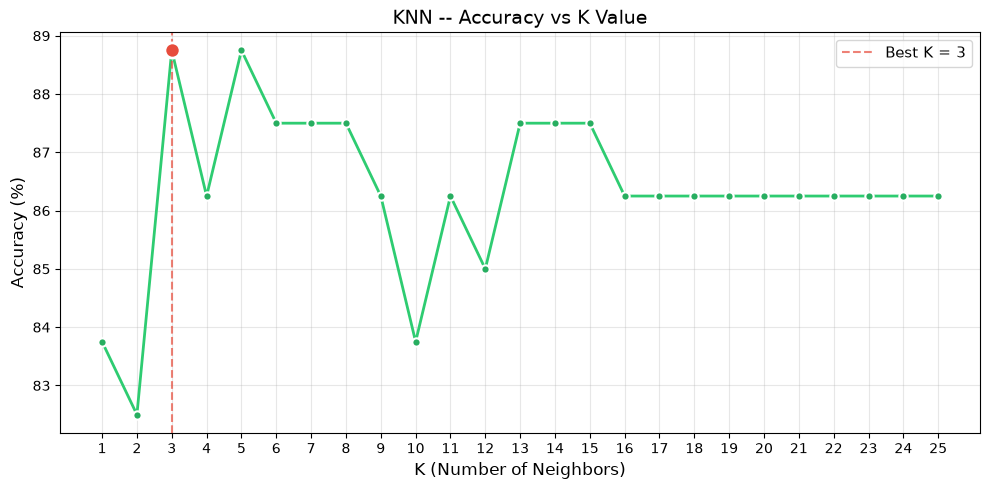


Best K = 3 with accuracy = 88.75%


In [ ]:

plt.figure(figsize=(10, 5))
plt.plot(list(k_values), [a * 100 for a in accuracies],
         marker='o', color='#2ecc71', linewidth=2, markersize=6,
         markerfacecolor='#27ae60', markeredgecolor='white', markeredgewidth=1.5)

best_k = list(k_values)[np.argmax(accuracies)]
best_acc = max(accuracies) * 100
plt.axvline(x=best_k, color='#e74c3c', linestyle='--', alpha=0.7, label=f'Best K = {best_k}')
plt.scatter([best_k], [best_acc], color='#e74c3c', s=120, zorder=5, edgecolors='white', linewidths=2)

plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('KNN -- Accuracy vs K Value', fontsize=14)
plt.xticks(list(k_values))
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest K = {best_k} with accuracy = {best_acc:.2f}%")

## Decision Boundary Visualization

Let's see how KNN **divides the feature space** using the best K value.


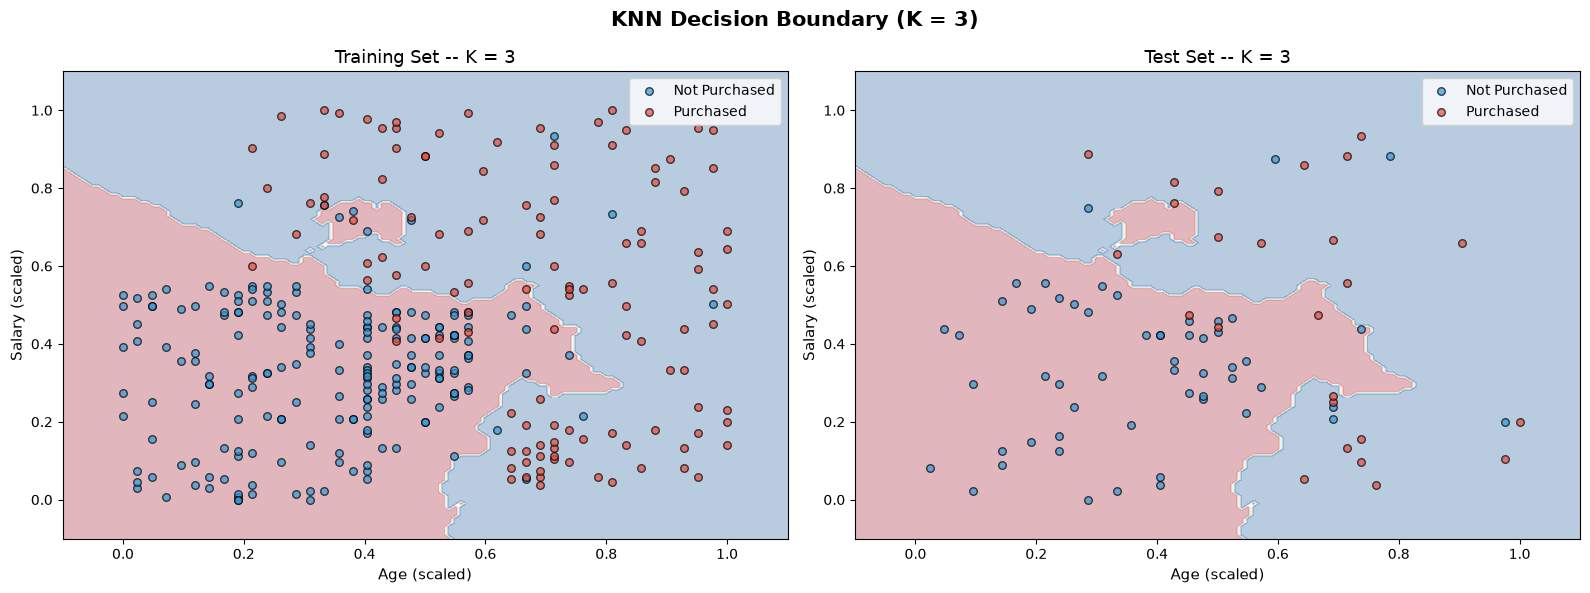

In [ ]:

def plot_decision_boundary(X_train, y_train, X_test, y_test, k):
    """Visualize the KNN decision boundary."""
    model = KNN(k=k)
    model.fit(X_train, y_train)


    h = 0.01  
    x_min, x_max = X_train[:, 0].min() - 0.1, X_train[:, 0].max() + 0.1
    y_min, y_max = X_train[:, 1].min() - 0.1, X_train[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, X_data, y_data, title in zip(
        axes,
        [X_train, X_test],
        [y_train, y_test],
        ['Training Set', 'Test Set']
    ):
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
        ax.scatter(X_data[y_data == 0, 0], X_data[y_data == 0, 1],
                   c='#3498db', label='Not Purchased', edgecolors='k', s=30, alpha=0.7)
        ax.scatter(X_data[y_data == 1, 0], X_data[y_data == 1, 1],
                   c='#e74c3c', label='Purchased', edgecolors='k', s=30, alpha=0.7)
        ax.set_xlabel('Age (scaled)', fontsize=11)
        ax.set_ylabel('Salary (scaled)', fontsize=11)
        ax.set_title(f'{title} -- K = {k}', fontsize=13)
        ax.legend()

    plt.suptitle(f'KNN Decision Boundary (K = {k})', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_decision_boundary(X_train_scaled, y_train, X_test_scaled, y_test, best_k)

## Conclusion

### What we built
We implemented the **K-Nearest Neighbors** algorithm **entirely from scratch** using only NumPy -- no scikit-learn.

### Key takeaways

| Concept | What we did |
|---------|-------------|
| **Distance** | Euclidean distance to measure similarity |
| **Voting** | Majority vote among K nearest neighbors |
| **Scaling** | Min-Max normalization so all features contribute equally |
| **Train/Test Split** | Manual shuffling and slicing with NumPy |
| **Evaluation** | Accuracy, confusion matrix, precision, recall, F1 -- all built by hand |
| **Tuning K** | Tested multiple K values and picked the best one |

### Pros & Cons of KNN

| Pros | Cons |
|------|------|
| Simple to understand and implement | Slow on large datasets (compares to every training point) |
| No training phase needed | Sensitive to irrelevant features |
| Works well for small datasets | Needs feature scaling |
| Non-parametric -- no assumptions about data distribution | Storage-heavy (stores all training data) |

---

*This notebook is part of the "ML Algorithms from Scratch" series.*
